# MCDI500 — Programación para la Ciencia de Datos
## Fase 4: Visualizaciones analíticas y comunicación de resultados

**Proyecto:** PROYECTO-GRUPO4-MCDI500  
**Integrantes:**
- Carolina Cortés Donoso
- Pedro Espinoza Vicentela
- Marcelo Corro Troncoso
- Juan Pablo Valdebenito Loyola

**Docente:** Omar Iván Salinas Silva  
**Fecha:** Junio 2026

# I. Introducción

Esta fase constituye el cierre integrador del proyecto. No incorpora nuevo contenido técnico, sino que consolida, valida y comunica los resultados obtenidos en las fases anteriores.

**Hilo conductor F1–F4:**

| Fase | Foco | Producto principal |
|------|------|--------------------|
| F1 | Definición del problema y entorno | Dataset crudo cargado, pregunta central |
| F2 | Preprocesamiento y transformación | wdbc_procesado.csv, pipeline funcional |
| F3 | Núcleo algorítmico y POO | Algoritmos de búsqueda, clases src/ |
| F4 | Visualizaciones y comunicación | Tres gráficos analíticos, storytelling |

**Pregunta central:**  
*¿Es posible predecir si un tumor mamario es benigno o maligno usando características morfológicas celulares?*

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../../src'))

RUTA_RAW       = '../../data/raw/wdbc.data'
RUTA_PROCESADO = '../../data/processed/wdbc_procesado.csv'

print('Python:', sys.version)
print('NumPy: ', np.__version__)
print('Pandas:', pd.__version__)

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
NumPy:  2.4.6
Pandas: 3.0.3


---
# II. Resumen F1 — Definición del problema y dataset crudo

En la Fase 1 se configuró el entorno reproducible, se identificó el dataset y se formuló la pregunta central del proyecto.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository (Dua & Graff, 2019).  
**Instancias:** 569 registros, 32 columnas (id, diagnóstico y 30 variables morfológicas celulares).  
**Variable objetivo:** diagnostico — B (benigno) / M (maligno).

In [2]:
COLUMNAS = [
    'id', 'diagnostico',
    'radio_mean', 'textura_mean', 'perimetro_mean', 'area_mean',
    'suavidad_mean', 'compacidad_mean', 'concavidad_mean', 'puntos_concavos_mean',
    'simetria_mean', 'dimension_fractal_mean',
    'radio_se', 'textura_se', 'perimetro_se', 'area_se',
    'suavidad_se', 'compacidad_se', 'concavidad_se', 'puntos_concavos_se',
    'simetria_se', 'dimension_fractal_se',
    'radio_worst', 'textura_worst', 'perimetro_worst', 'area_worst',
    'suavidad_worst', 'compacidad_worst', 'concavidad_worst', 'puntos_concavos_worst',
    'simetria_worst', 'dimension_fractal_worst'
]

df_crudo = pd.read_csv(RUTA_RAW, header=None, names=COLUMNAS)

print(f'Forma del dataset crudo: {df_crudo.shape[0]} filas x {df_crudo.shape[1]} columnas')
print(f'Distribucion diagnostico: {df_crudo["diagnostico"].value_counts().to_dict()}')
print(f'Valores NA: {df_crudo.isna().sum().sum()}')
df_crudo.head(3)

Forma del dataset crudo: 569 filas x 32 columnas
Distribucion diagnostico: {'B': 357, 'M': 212}
Valores NA: 0


,id,diagnostico,radio_mean,textura_mean,perimetro_mean,area_mean,suavidad_mean,compacidad_mean,concavidad_mean,puntos_concavos_mean,...,radio_worst,textura_worst,perimetro_worst,area_worst,suavidad_worst,compacidad_worst,concavidad_worst,puntos_concavos_worst,simetria_worst,dimension_fractal_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


---
# III. Resumen F2 — Preprocesamiento y transformación

En la Fase 2 se construyó el pipeline de limpieza y transformación. En la Fase 3 fue encapsulado en la clase Preprocesador (src/preprocesador.py).

| Paso | Método | Justificación |
|------|--------|---------------|
| Eliminar id | .eliminar_columnas(['id']) | Identificador sin valor predictivo |
| Eliminar duplicados | .eliminar_duplicados() | Integridad del dataset |
| Imputar NA | .imputar_na(estrategia='mediana') | Robustez ante outliers |
| Codificar diagnóstico | .codificar_diagnostico() | B→0, M→1 para análisis numérico |
| Estandarizar | .estandarizar() | StandardScaler: media≈0, std≈1 |
| Validar | .validar() | Assertions automáticas de integridad |

In [3]:
df_proc = pd.read_csv(RUTA_PROCESADO)

print(f'Forma procesada: {df_proc.shape[0]} filas x {df_proc.shape[1]} columnas')
print(f'Valores NA: {df_proc.isna().sum().sum()}')
print(f'Distribucion diagnostico: {df_proc["diagnostico"].value_counts().to_dict()}')
print(f'Media radio_mean (aprox. 0): {df_proc["radio_mean"].mean():.6f}')
print(f'Std  radio_mean (aprox. 1): {df_proc["radio_mean"].std(ddof=0):.6f}')
df_proc.head(3)

Forma procesada: 569 filas x 31 columnas
Valores NA: 0
Distribucion diagnostico: {0: 357, 1: 212}
Media radio_mean (aprox. 0): -0.000000
Std  radio_mean (aprox. 1): 1.000000


,diagnostico,radio_mean,textura_mean,perimetro_mean,area_mean,suavidad_mean,compacidad_mean,concavidad_mean,puntos_concavos_mean,simetria_mean,...,radio_worst,textura_worst,perimetro_worst,area_worst,suavidad_worst,compacidad_worst,concavidad_worst,puntos_concavos_worst,simetria_worst,dimension_fractal_worst
0,1,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391


---
# IV. Resumen F3 — Núcleo algorítmico y POO

En la Fase 3 se implementaron algoritmos de búsqueda (O(n) iterativo y O(log n) recursivo) y se introdujo POO mediante clases abstractas y concretas en src/.

| Archivo | Clase(s) | Responsabilidad |
|---------|----------|-----------------|
| src/base.py | Transformador (ABC) | Contrato abstracto aplicar(df) |
| src/preprocesador.py | Preprocesador | Pipeline F2 encapsulado, métodos encadenables |
| src/transformadores.py | EliminadorColumnas, ImputadorNA, CodificadorDiagnostico, EscaladorNumerico | Subclases concretas de Transformador |
| src/pipeline.py | Pipeline | Orquesta transformadores (polimorfismo) |
| src/buscadores.py | BuscadorLineal, BuscadorBinario | Búsqueda O(n) y O(log n) con interfaz común |
| src/algoritmos.py | Funciones | Versión funcional: búsquedas y filtro de correlación |

In [4]:
from algoritmos import busqueda_lineal_iterativa, busqueda_binaria_recursiva, filtro_estructurado_features
from buscadores import BuscadorLineal, BuscadorBinario
from preprocesador import Preprocesador

arreglo = sorted(df_proc['radio_mean'].tolist())
objetivo = arreglo[len(arreglo) // 2]

idx_lineal  = busqueda_lineal_iterativa(arreglo, objetivo)
idx_binaria = busqueda_binaria_recursiva(arreglo, objetivo, 0, len(arreglo) - 1)

print(f'Busqueda lineal  -> indice: {idx_lineal}')
print(f'Busqueda binaria -> indice: {idx_binaria}')
assert idx_lineal == idx_binaria

buscador_poo = BuscadorBinario(df_proc['radio_mean'].tolist())
print(f'BuscadorBinario (POO) -> indice: {buscador_poo.buscar(objetivo)}')

pares = filtro_estructurado_features(df_proc.drop(columns=['diagnostico']), umbral_correlacion=0.8)
print(f'Pares con correlacion > 0.8: {len(pares)}')
print(f'Par de mayor correlacion: {pares[0]}')

Busqueda lineal  -> indice: 284
Busqueda binaria -> indice: 284
BuscadorBinario (POO) -> indice: 284
Pares con correlacion > 0.8: 44
Par de mayor correlacion: ('radio_mean', 'perimetro_mean', 0.9979)


---
# VII.a Preprocesamiento y validación del dataset para visualización

Antes de construir las visualizaciones se verifica que df_proc cumple todas las condiciones necesarias: sin valores faltantes, variable objetivo codificada como entero {0, 1} y variables morfológicas estandarizadas.

El dataset proviene directamente del pipeline de F2 (wdbc_procesado.csv) y no requiere transformaciones adicionales.

In [5]:
assert df_proc.isna().sum().sum() == 0, 'Hay valores NA'
assert set(df_proc['diagnostico'].unique()) == {0, 1}, 'diagnostico debe contener solo 0 y 1'
assert df_proc.shape == (569, 31), f'Forma inesperada: {df_proc.shape}'

vars_morfologicas = [c for c in df_proc.columns if c != 'diagnostico']
n_benigno = (df_proc['diagnostico'] == 0).sum()
n_maligno = (df_proc['diagnostico'] == 1).sum()

print('Dataset validado y listo para visualizacion')
print(f'  Filas             : {df_proc.shape[0]}')
print(f'  Columnas          : {df_proc.shape[1]}')
print(f'  Benignos (0)      : {n_benigno}')
print(f'  Malignos (1)      : {n_maligno}')
print(f'  Variables morfol. : {len(vars_morfologicas)}')
print(f'  Valores NA        : {df_proc.isna().sum().sum()}')
print('Todas las validaciones pasaron correctamente.')

Dataset validado y listo para visualizacion
  Filas             : 569
  Columnas          : 31
  Benignos (0)      : 357
  Malignos (1)      : 212
  Variables morfol. : 30


  Valores NA        : 0
Todas las validaciones pasaron correctamente.


---
# VII.b Gráfico 1 — Distribución de diagnósticos

El primer gráfico da contexto al problema: ¿cuántos casos benignos y malignos tiene el dataset?
Antes de analizar cualquier variable morfológica, es necesario entender la composición del conjunto de datos,
ya que un desbalance severo afecta directamente la interpretación de los resultados.

**Fuente:** Dua & Graff (2019). UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic).

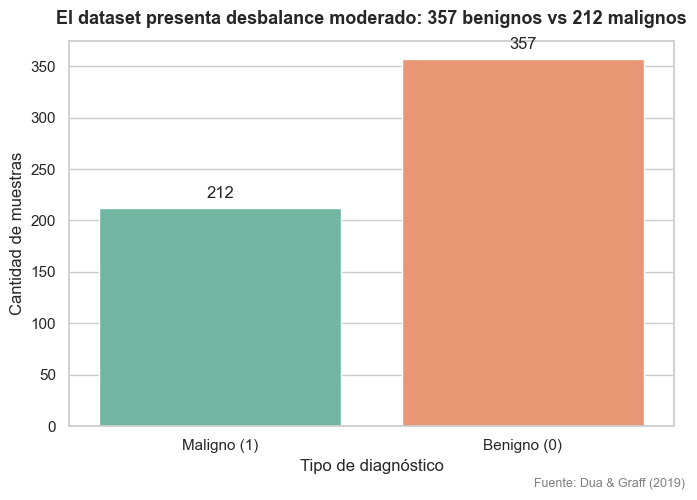

In [6]:
sns.set_theme(style='whitegrid', palette='Set2')

df_proc['Etiqueta_Diagnostico'] = df_proc['diagnostico'].map({1: 'Maligno (1)', 0: 'Benigno (0)'})

fig1, ax1 = plt.subplots(figsize=(7, 5))

sns.countplot(
    data=df_proc,
    x='Etiqueta_Diagnostico',
    hue='Etiqueta_Diagnostico',
    dodge=False,
    legend=False,
    ax=ax1
)

for p in ax1.patches:
    ax1.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=12,
        xytext=(0, 5), textcoords='offset points'
    )

ax1.set_title(
    'El dataset presenta desbalance moderado: 357 benignos vs 212 malignos',
    fontsize=13, fontweight='bold', pad=12
)
ax1.set_xlabel('Tipo de diagnóstico', fontsize=12)
ax1.set_ylabel('Cantidad de muestras', fontsize=12)
fig1.text(0.99, 0.01, 'Fuente: Dua & Graff (2019)', ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Interpretación:** El dataset cuenta con 357 casos benignos (62.7%) y 212 malignos (37.3%). El desbalance existe, pero es moderado: no compromete el análisis ni requiere técnicas de balanceo para exploración visual. Lo relevante es tenerlo presente al interpretar los gráficos siguientes, ya que una variable que separa bien los grupos a pesar del desbalance tiene mayor valor predictivo.

---
# VII.c Gráfico 2 — Radio celular medio por diagnóstico

Una vez establecido el contexto, el siguiente paso es verificar si alguna variable morfológica
por sí sola logra separar los grupos. Se escoge `radio_mean` porque es la característica más
directamente relacionada con el tamaño del tumor, y porque el filtro de correlación de F3
identificó que concentra alta correlación con otras variables de área y perímetro.

**Fuente:** Dua & Graff (2019). UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic).

C:\Users\hellb\AppData\Local\Temp\ipykernel_20348\415937188.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='Diagnóstico', loc='upper left')


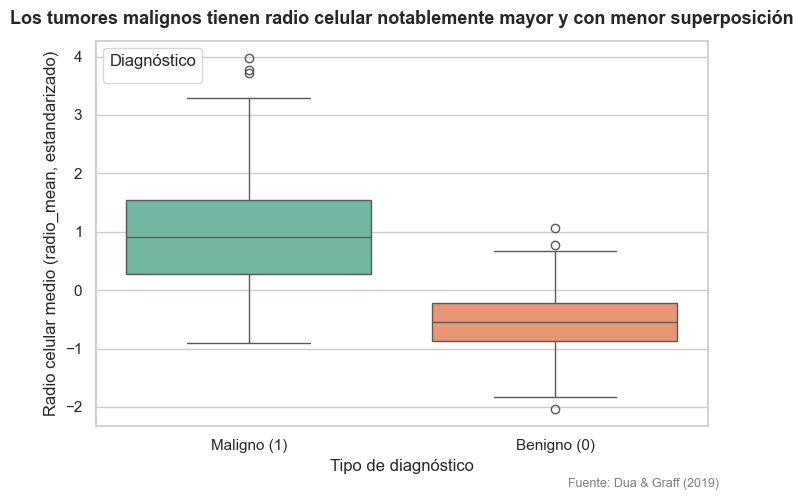

In [7]:
fig2, ax2 = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_proc,
    x='Etiqueta_Diagnostico',
    y='radio_mean',
    hue='Etiqueta_Diagnostico',
    dodge=False,
    ax=ax2
)

ax2.set_title(
    'Los tumores malignos tienen radio celular notablemente mayor y con menor superposición',
    fontsize=13, fontweight='bold', pad=12
)
ax2.set_xlabel('Tipo de diagnóstico', fontsize=12)
ax2.set_ylabel('Radio celular medio (radio_mean, estandarizado)', fontsize=12)
ax2.legend(title='Diagnóstico', loc='upper left')
fig2.text(0.99, 0.01, 'Fuente: Dua & Graff (2019)', ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Interpretación:** Los tumores malignos presentan un radio celular medio significativamente mayor que los benignos. Las cajas tienen poca superposición, lo que indica que esta variable sola ya tiene poder discriminativo. Esto responde parcialmente la pregunta central del proyecto: las características morfológicas no solo son descriptivas, sino que permiten distinguir entre tumores benignos y malignos con cierto grado de confianza. Los valores están estandarizados (media≈0, std≈1), por lo que la escala refleja desviaciones respecto al promedio del dataset.

---
# VII.d Gráfico 3 — Correlación entre variables morfológicas

El tercer gráfico cierra la historia: si una sola variable ya separa los grupos, ¿qué pasa con el conjunto completo de características morfológicas? El heatmap muestra si las variables son independientes entre sí o si comparten información.

El dataset contiene 30 variables, pero están organizadas en 10 características base (`radio`, `textura`, `perímetro`, etc.) medidas en tres estadísticos: valor medio (`_mean`), error estándar (`_se`) y peor valor (`_worst`). Para mantener la legibilidad del gráfico y comunicar el patrón con claridad, se visualizan solo las 10 variables `_mean`, que son las más representativas de cada característica morfológica. El patrón de correlación es equivalente en los tres grupos estadísticos.

Esto conecta directamente con `filtro_estructurado_features` de F3, que encontró numerosos pares con correlación superior a 0.8.

**Fuente:** Dua & Graff (2019). UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic).

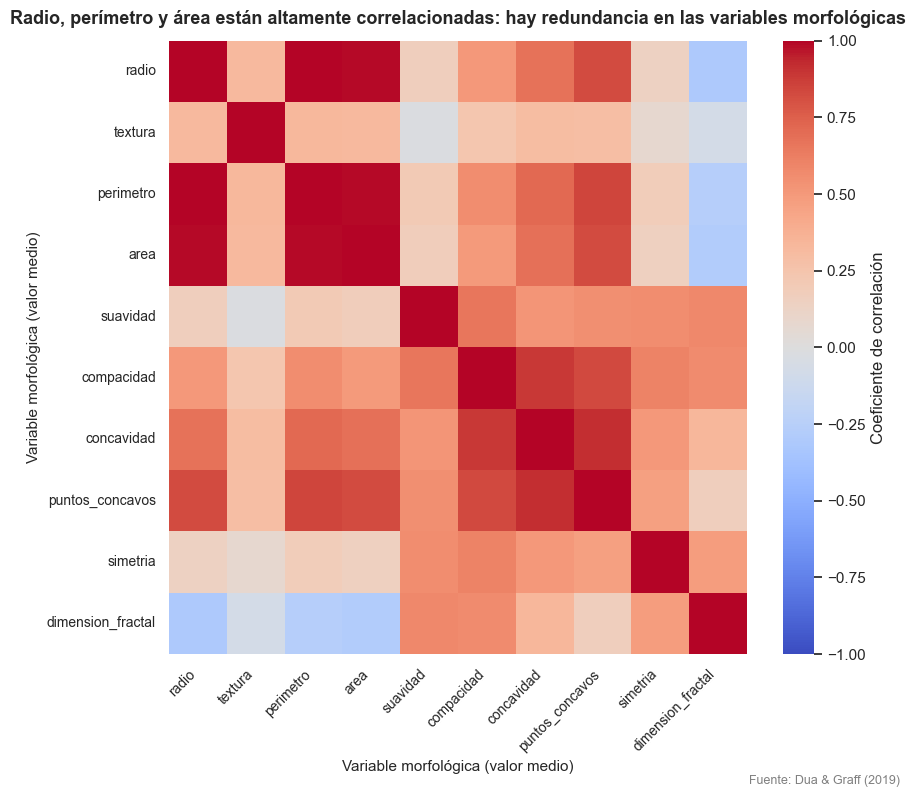

In [8]:
vars_mean = [c for c in df_proc.columns if c.endswith('_mean')]
corr_mean = df_proc[vars_mean].corr()

# Etiquetas más cortas: quitar sufijo '_mean' para que entren bien en el gráfico
etiquetas = [v.replace('_mean', '') for v in vars_mean]

fig3, ax3 = plt.subplots(figsize=(9, 8))

sns.heatmap(
    corr_mean,
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    annot=False,
    ax=ax3,
    cbar_kws={'label': 'Coeficiente de correlación'}
)

ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=10)

ax3.set_title(
    'Radio, perímetro y área están altamente correlacionadas: hay redundancia en las variables morfológicas',
    fontsize=13, fontweight='bold', pad=12
)
ax3.set_xlabel('Variable morfológica (valor medio)', fontsize=11)
ax3.set_ylabel('Variable morfológica (valor medio)', fontsize=11)
fig3.text(0.99, 0.01, 'Fuente: Dua & Graff (2019)', ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Interpretación:** El heatmap muestra claramente que `radio`, `perímetro` y `área` están muy correlacionadas entre sí (valores cercanos a 1.0), lo que tiene sentido: son medidas geométricas del mismo fenómeno físico. Lo mismo ocurre con `concavidad` y `puntos_concavos`. Este patrón confirma lo que `filtro_estructurado_features` detectó programáticamente en F3: existe redundancia importante en el dataset. En la práctica, un modelo predictivo no necesitaría las 30 variables para funcionar bien; un subconjunto pequeño podría capturar la mayor parte de la información. Se visualizan las 10 variables `_mean` porque son representativas de cada característica morfológica y permiten leer los nombres con claridad; el patrón de correlación es consistente en los grupos `_se` y `_worst`.

---
# VIII. Reflexión técnica grupal

## Eficiencia y decisiones de optimización

A lo largo del proyecto se tomaron decisiones conscientes sobre eficiencia algorítmica. En F3 se implementaron y compararon una búsqueda lineal O(n) y una búsqueda binaria O(log n) usando `timeit`, lo que permitió verificar empíricamente que la versión recursiva es más eficiente para datasets ordenados de mediano y gran tamaño. El filtro de correlación `filtro_estructurado_features` opera en O(n²) sobre las variables, lo cual es aceptable para 30 características, pero escalaría mal con datasets de alta dimensionalidad.

Para las visualizaciones de esta fase se optó por `seaborn` sobre `matplotlib` puro, ya que reduce el código necesario y produce gráficos estadísticamente más informativos (intervalos de confianza, distribución de outliers en boxplots) sin sacrificar rendimiento.

## Escalabilidad del diseño

El uso de POO en `src/` facilitó que el pipeline de preprocesamiento fuera reutilizable en distintas fases sin duplicar código. La clase `Preprocesador` con métodos encadenables y la clase abstracta `Transformador` permiten agregar nuevas transformaciones con mínimo impacto en el resto del sistema. Si el proyecto escalara a un dataset con cientos de variables o millones de registros, el cuello de botella estaría en el filtro de correlación O(n²) y en la estandarización cargada en memoria, que deberían reemplazarse por soluciones incrementales o por lotes.

## Comparación entre fases

| Aspecto | F1–F2 | F3 | F4 |
|---------|-------|----|----|
| Estructura del código | Funciones sueltas | Clases y módulos src/ | Integración y reutilización |
| Validación | Manual (prints) | Assertions sistemáticas | Assertions + evidencia visual |
| Comunicación | Tablas y prints | Outputs de benchmark | Gráficos con storytelling |
| Reproducibilidad | Notebook independiente | Imports desde src/ | Pipeline F1–F4 integrado |

## Aprendizajes del equipo

El mayor aprendizaje de esta fase fue que los datos tienen que contar una historia coherente: no basta con producir gráficos correctos técnicamente, sino que cada visualización debe responder una pregunta concreta y conectarse con las anteriores. Trabajar con un dataset real también evidenció que la correlación entre variables morfológicas no es una anomalía, sino una propiedad biológica: el tamaño de una célula tumoral tiende a afectar simultáneamente su radio, perímetro y área. Eso tiene implicancias directas para cualquier modelo predictivo que se construya sobre este dataset.

---
# IX. Bibliografía

Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Science. https://archive.ics.uci.edu/ml/index.php

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Salinas Silva, O. I. (2026a). *Apuntes de algoritmos y complejidad computacional* [Material del curso MCDI500]. Universidad Andrés Bello.

Salinas Silva, O. I. (2026b). *Guía de desarrollo — Sumativa 4 (Fase 4)* [Material del curso MCDI500]. Universidad Andrés Bello.

scikit-learn developers. (2024). *scikit-learn: Machine learning in Python* (v1.5). https://scikit-learn.org

Waskom, M. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021
